✅ Notebook 02 Initialized.
Cleaned Data Loaded: 4056 materials (Step 1 Outliers Removed).


C:\Users\HP\AppData\Local\Temp\ipykernel_10400\3751690043.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='B_site', palette='viridis', order=df['B_site'].value_counts().index)


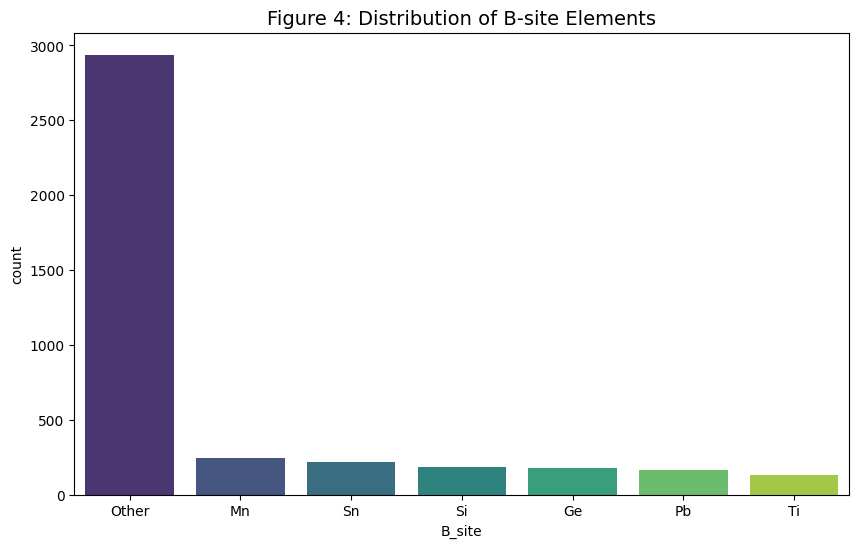


--- B-site Statistics ---
B_site
Other    2938
Mn        244
Sn        216
Si        186
Ge        176
Pb        167
Ti        129
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. LOAD AND RE-CLEAN (Since no CSV was saved)
df_raw = pd.read_csv('ML_Final_Sheet.csv') # Path to your original file

# Re-applying the Step 1 Z-Score Clean (to get back to 4056 rows)
numeric_df = df_raw.select_dtypes(include=[np.number])
z_scores = np.abs(stats.zscore(numeric_df))
df = df_raw[(z_scores < 3).all(axis=1)].copy()

print(f"Notebook 02 Initialized.")
print(f"Cleaned Data Loaded: {df.shape[0]} materials (Step 1 Outliers Removed).")

# 2. B-SITE IDENTITY EXTRACTION
def get_b_site(formula):
    # Identifying major B-site metals in your dataset
    if 'Pb' in formula: return 'Pb'
    if 'Sn' in formula: return 'Sn'
    if 'Ge' in formula: return 'Ge'
    if 'Ti' in formula: return 'Ti'
    if 'Si' in formula: return 'Si'
    if 'Mn' in formula: return 'Mn'
    return 'Other'

df['B_site'] = df['formula'].apply(get_b_site)

# 3. VISUALIZATION
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='B_site', palette='viridis', order=df['B_site'].value_counts().index)
plt.title('Figure 4: Distribution of B-site Elements', fontsize=14)
plt.show()

print("\n--- B-site Statistics ---")
print(df['B_site'].value_counts())

In [2]:
# 1. ELECTRONIC INTERACTION (The 'Ionicity' of the B-X bond)
# This represents the strength of the chemical bond that creates the bandgap.
df['chi_diff_BX'] = (df['chi_B'] - df['chi_X']).abs()

# 2. GEOMETRIC STRESS (Radius Ratio)
# This determines the octahedral stability (Critical for solar cell stability)
df['r_ratio_BX'] = df['rB'] / df['rX']

# 3. LATTICE ANISOTROPY (Structural Strain)
# We calculate the standard deviation of a, b, and c to see how 'non-cubic' it is.
# A perfect cube has distortion = 0.
df['lattice_strain'] = df[['a', 'b', 'c']].std(axis=1) / df[['a', 'b', 'c']].mean(axis=1)

# 4. ATOMIC PACKING FRACTION (APF)
# How much space is occupied vs. empty? (Physics: Higher APF usually means smaller bandgap)
# Formula: Total Spherical Volume of (A + B + 3X) / Unit Cell Volume
atomic_vol = (4/3) * np.pi * (df['rA']**3 + df['rB']**3 + 3*df['rX']**3)
df['packing_index'] = atomic_vol / df['volume']

# 5. VERIFICATION
print("--- Physics-Informed Descriptors Added ---")
print(df[['chi_diff_BX', 'lattice_strain', 'packing_index']].head())

# Quick Statistical Check to see if our descriptors are 'Healthy'
print("\nDescriptor Statistics:")
print(df[['chi_diff_BX', 'lattice_strain', 'packing_index']].describe().T[['mean', 'std', 'min', 'max']])

--- Physics-Informed Descriptors Added ---
   chi_diff_BX  lattice_strain  packing_index
0         1.83        0.000000       0.605814
1         1.40        0.000000       0.655801
2         1.78        0.000004       0.602902
3         1.54        0.000000       0.597807
4         1.61        0.000002       0.584359

Descriptor Statistics:
                    mean       std       min       max
chi_diff_BX     1.419845  0.599069  0.000000  3.050000
lattice_strain  0.147795  0.194995  0.000000  0.967900
packing_index   0.233040  0.200509  0.007683  0.810774


In [ ]:
# 1. STRUCTURAL CONFLICT RESOLUTION
# We group by chemistry AND lattice constants to handle those 568 polymorphs.
# We take the mean of the bandgap if there are any tiny microscopic duplicates left.
final_features = [
    'formula', 'B_site', 'band_gap', 'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 
    'EA_A', 'EA_B', 'EA_X', 'tolerance_factor', 'octahedral_factor', 
    'a', 'b', 'c', 'volume', 'density', 
    'chi_diff_BX', 'r_ratio_BX', 'lattice_strain', 'packing_index'
]

# Filtering to keep only our important columns
df_final = df[final_features]

# Deduplication logic
df_final = df_final.groupby(['formula', 'a', 'b', 'c']).mean(numeric_only=True).reset_index()

# 2. SAVE TO NEW CSV
file_name = 'Refined_Physics_Data.csv'
df_final.to_csv(file_name, index=False)

print(f"Success! Your research database is now saved as: {file_name}")
print(f"Final Dataset Shape: {df_final.shape}")
print(f"Columns ready for ML: {df_final.columns.tolist()}")

# 3. Quick Peak at the "Golden" Data
print("\nFirst 5 rows of your new database:")
display(df_final.head())

✅ Success! Your research database is now saved as: Refined_Physics_Data.csv
Final Dataset Shape: (4012, 22)
Columns ready for ML: ['formula', 'a', 'b', 'c', 'band_gap', 'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 'tolerance_factor', 'octahedral_factor', 'volume', 'density', 'chi_diff_BX', 'r_ratio_BX', 'lattice_strain', 'packing_index']

First 5 rows of your new database:


,formula,a,b,c,band_gap,rA,rB,rX,chi_A,chi_B,...,EA_B,EA_X,tolerance_factor,octahedral_factor,volume,density,chi_diff_BX,r_ratio_BX,lattice_strain,packing_index
0,AcAlO3,3.858634,3.858634,3.858634,4.1024,1.26,0.6750,1.26,1.1,1.61,...,0.432835,1.461113,0.921022,0.535714,57.451413,8.728230,1.83,0.535714,0.000000,0.605814
1,AcBO3,3.721668,3.721668,3.721668,0.8071,1.26,0.4100,1.26,1.1,2.04,...,0.279723,1.461113,1.067173,0.325397,51.548126,9.206879,1.40,0.325397,0.000000,0.655801
2,AcCrO3,3.944287,3.944302,3.944272,2.0031,1.26,0.9400,1.26,1.1,1.66,...,0.675928,1.461113,0.810081,0.746032,61.362845,8.848788,1.78,0.746032,0.000004,0.602902
3,AcCuO3,3.913331,3.913331,3.913331,0.0000,1.26,0.8200,1.26,1.1,1.90,...,1.235784,1.461113,0.856816,0.650794,59.929387,9.380471,1.54,0.650794,0.000000,0.597807
4,AcFeO3,3.953570,3.953568,3.953585,0.9888,1.26,0.8525,1.26,1.1,1.83,...,0.153236,1.461113,0.843635,0.676587,61.797311,8.889999,1.61,0.676587,0.000002,0.584359


--- PCA Deep Dive ---
Information retained in PC1: 69.34%
Information retained in PC2: 21.89%
Total variance captured: 91.22%


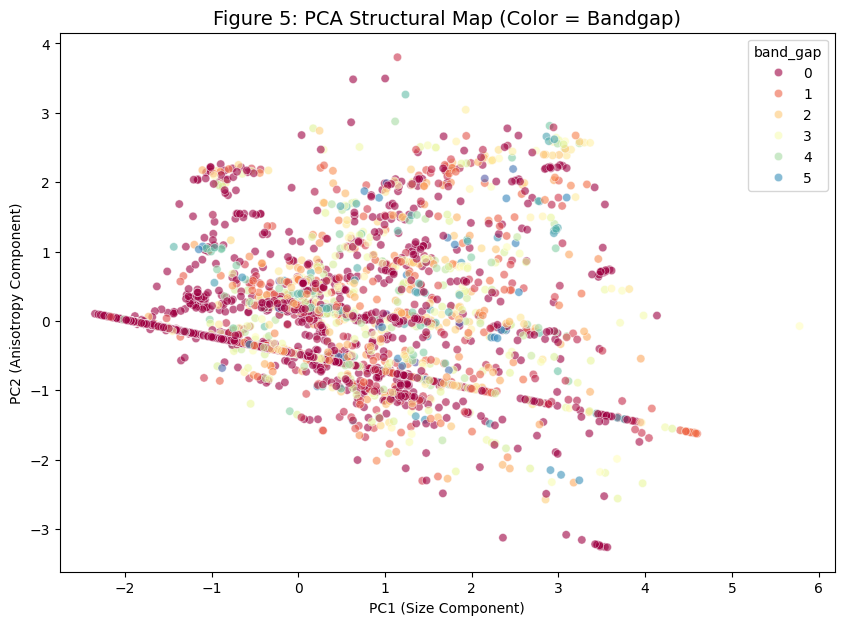

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. ISOLATE THE LATTICE PARAMETERS
lattice_params = ['a', 'b', 'c']
x_lattice = df_final[lattice_params]

# 2. STANDARDIZE (PCA needs data to be on the same scale)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_lattice)

# 3. APPLY PCA
# We will reduce 3 variables (a,b,c) into 2 components
pca = PCA(n_components=2)
lattice_pca = pca.fit_transform(x_scaled)

# Add them to our final dataframe
df_final['PC1_Size'] = lattice_pca[:, 0]
df_final['PC2_Shape'] = lattice_pca[:, 1]

# 4. EXPLAINED VARIANCE (How much info did we keep?)
explained_var = pca.explained_variance_ratio_
print(f"--- PCA Deep Dive ---")
print(f"Information retained in PC1: {explained_var[0]*100:.2f}%")
print(f"Information retained in PC2: {explained_var[1]*100:.2f}%")
print(f"Total variance captured: {sum(explained_var)*100:.2f}%")

# 5. VISUALIZE THE "STRUCTURAL UNIVERSE"
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_final, x='PC1_Size', y='PC2_Shape', hue='band_gap', palette='Spectral', alpha=0.6)
plt.title('Figure 5: PCA Structural Map (Color = Bandgap)', fontsize=14)
plt.xlabel('PC1 (Size Component)')
plt.ylabel('PC2 (Anisotropy Component)')
plt.show()

In [ ]:
# Save the final version with Engineered Features AND PCA Components
df_final.to_csv('Refined_Physics_Data_V2.csv', index=False)

print("Master Database Saved: Refined_Physics_Data_V2.csv")
print(f"Final Column Count: {len(df_final.columns)}")
print("Step 2 is now 100% COMPLETE.")

✅ Master Database Saved: Refined_Physics_Data_V2.csv
Final Column Count: 24
Step 2 is now 100% COMPLETE.


C:\Users\HP\AppData\Local\Temp\ipykernel_10400\1844508747.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Stability_Tag', palette='coolwarm')


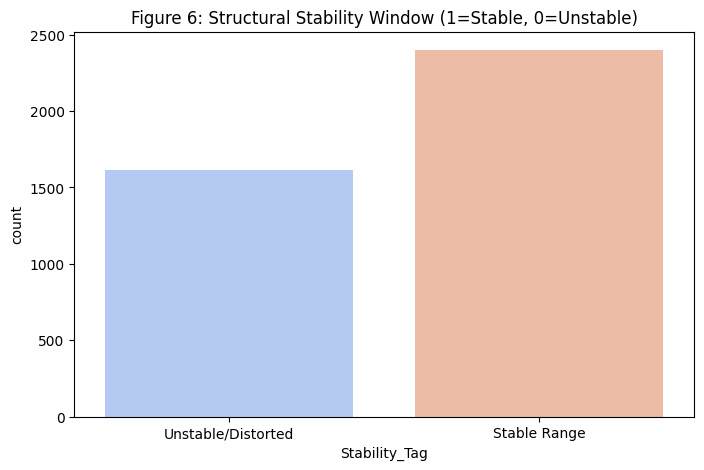

--- Step 2 Finalized ---
Materials in 'Stable Window': 2400
Master File Updated: Refined_Physics_Data_V2.csv


In [7]:
# 1. DEFINE THE STABILITY WINDOW
def tag_stability(t):
    if 0.8 <= t <= 1.1:
        return 1 # Stable
    else:
        return 0 # Unstable/Distorted

df_final['Stability_Tag'] = df_final['tolerance_factor'].apply(tag_stability)

# 2. VISUALIZE THE STABILITY DISTRIBUTION
plt.figure(figsize=(8, 5))
sns.countplot(data=df_final, x='Stability_Tag', palette='coolwarm')
plt.title('Figure 6: Structural Stability Window (1=Stable, 0=Unstable)')
plt.xticks([0, 1], ['Unstable/Distorted', 'Stable Range'])
plt.show()

# 3. SAVE THE ABSOLUTE FINAL VERSION
df_final.to_csv('Refined_Physics_Data_V2.csv', index=False)

print("--- Step 2 Finalized ---")
print(f"Materials in 'Stable Window': {df_final['Stability_Tag'].sum()}")
print("Master File Updated: Refined_Physics_Data_V2.csv")

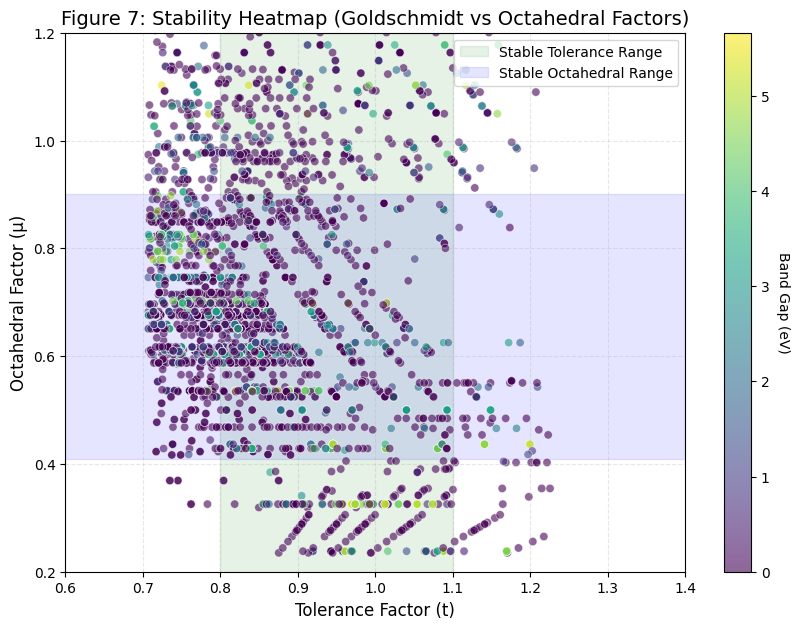

--- Stability Analysis ---
Total Materials: 4012
Total Semiconductors (>0eV) in Stable Window: 1017
Percentage of candidates in the 'Ideal Box': 25.35%


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the finalized data (ensuring we have the latest V2)
df_heatmap = pd.read_csv('Refined_Physics_Data_V2.csv')

# 2. Create the Stability Heatmap
plt.figure(figsize=(10, 7))

# Define the physical stability boundaries
# Tolerance Factor (t): 0.8 to 1.1 is the 'Goldschmidt' window
# Octahedral Factor (mu): 0.41 to 0.9 is the 'Octahedral' stability window
plt.axvspan(0.8, 1.1, color='green', alpha=0.1, label='Stable Tolerance Range')
plt.axhspan(0.41, 0.9, color='blue', alpha=0.1, label='Stable Octahedral Range')

# Plot all materials colored by their Band Gap
scatter = plt.scatter(df_heatmap['tolerance_factor'], 
                     df_heatmap['octahedral_factor'], 
                     c=df_heatmap['band_gap'], 
                     cmap='viridis', 
                     alpha=0.6, 
                     edgecolors='w', 
                     linewidth=0.5)

# Add a colorbar to show bandgap values
cbar = plt.colorbar(scatter)
cbar.set_label('Band Gap (eV)', rotation=270, labelpad=15)

# Labels and Formatting
plt.title('Figure 7: Stability Heatmap (Goldschmidt vs Octahedral Factors)', fontsize=14)
plt.xlabel('Tolerance Factor (t)', fontsize=12)
plt.ylabel('Octahedral Factor (μ)', fontsize=12)
plt.xlim(0.6, 1.4) # Zooming in on the relevant area
plt.ylim(0.2, 1.2)
plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='upper right')

# 3. SAVE THE IMAGE FOR YOUR REPORT
plt.savefig('Stability_Heatmap.png', dpi=300)
plt.show()

# 4. Final Statistics for your Dissertation text
stable_semi = df_heatmap[(df_heatmap['tolerance_factor'] >= 0.8) & 
                         (df_heatmap['tolerance_factor'] <= 1.1) & 
                         (df_heatmap['band_gap'] > 0)]

print(f"--- Stability Analysis ---")
print(f"Total Materials: {len(df_heatmap)}")
print(f"Total Semiconductors (>0eV) in Stable Window: {len(stable_semi)}")
print(f"Percentage of candidates in the 'Ideal Box': {(len(stable_semi)/len(df_heatmap))*100:.2f}%")